# 从 Baseline 开始做后续优化

前一次 `02_submission_cleaning_modeling.csv` 的 Kaggle 公榜分数不如 `01_submission_baseline.csv`，说明一次性加入太多清洗和特征工程会带来不稳定风险。

这个 notebook 的策略是：以 baseline 为起点，每次只加入一个明确改动，并用同一套交叉验证方式比较。

## 1. 导入依赖与读取数据

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
SUBMISSION_DIR = ROOT / "submissions"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

train.shape, test.shape

((1460, 81), (1459, 80))

## 2. 公共函数

这里保留 baseline 的核心思想：

- 数值特征：中位数填充 + 标准化。
- 类别特征：众数填充 + one-hot 编码。
- 目标变量：使用 `log1p(SalePrice)` 建模，预测后用 `expm1` 还原。

In [2]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_pred = np.maximum(y_pred, 0)
    return float(np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred))))


def build_ridge_model(X: pd.DataFrame) -> TransformedTargetRegressor:
    numeric_features = X.select_dtypes(include="number").columns.tolist()
    categorical_features = X.select_dtypes(exclude="number").columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ]
    )

    regressor = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ]
    )

    return TransformedTargetRegressor(
        regressor=regressor,
        func=np.log1p,
        inverse_func=np.expm1,
    )


def cross_validate_model(model, X: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> float:
    scores = []
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, valid_idx in cv.split(X):
        fold_model = clone(model)
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        fold_model.fit(X_train, y_train)
        predictions = fold_model.predict(X_valid)
        scores.append(rmsle(y_valid.to_numpy(), predictions))

    return float(np.mean(scores))

## 3. 准备 baseline 数据

这里完全沿用 baseline 的输入方式：只删除 `Id`，不做额外清洗。这样后续实验都能和 baseline 公平比较。

In [3]:
target = "SalePrice"
id_column = "Id"

X_base = train.drop(columns=[target, id_column])
y_base = train[target]
X_test_base = test.drop(columns=[id_column])
test_ids = test[id_column]

X_base.shape, X_test_base.shape

((1460, 79), (1459, 79))

## 4. 实验 A：复现 baseline

先确认本 notebook 里的 baseline 分数和脚本版接近。

In [4]:
baseline_model = build_ridge_model(X_base)
baseline_cv = cross_validate_model(baseline_model, X_base, y_base)
baseline_cv

0.1468523843843354

## 5. 实验 B：只移除明显异常点

EDA 中发现 `GrLivArea` 很大但售价较低的样本可能影响线性模型。这里只移除训练集中非常明显的异常点，不改测试集。

In [5]:
outlier_mask = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
train_outlier_removed = train.loc[~outlier_mask].copy()

X_no_outliers = train_outlier_removed.drop(columns=[target, id_column])
y_no_outliers = train_outlier_removed[target]

print("移除异常点数量:", int(outlier_mask.sum()))
print("异常点 Id:", train.loc[outlier_mask, "Id"].tolist())

no_outlier_model = build_ridge_model(X_no_outliers)
no_outlier_cv = cross_validate_model(no_outlier_model, X_no_outliers, y_no_outliers)
no_outlier_cv

移除异常点数量: 2
异常点 Id: [524, 1299]


0.11508839668253472

## 6. 实验 C：只对偏态数值特征做 log1p

很多面积、价格以外的计数类数值特征也右偏。这个实验只处理数值特征偏态，不加入其他新特征。

In [6]:
def log_transform_skewed_features(X_train: pd.DataFrame, X_test: pd.DataFrame, threshold: float = 0.75):
    X_train = X_train.copy()
    X_test = X_test.copy()

    numeric_columns = X_train.select_dtypes(include="number").columns
    skewness = X_train[numeric_columns].skew().sort_values(ascending=False)
    skewed_columns = skewness[skewness > threshold].index.tolist()

    for column in skewed_columns:
        min_value = min(X_train[column].min(), X_test[column].min())
        if pd.notna(min_value) and min_value >= 0:
            X_train[column] = np.log1p(X_train[column])
            X_test[column] = np.log1p(X_test[column])

    return X_train, X_test, skewed_columns


X_log, X_test_log, skewed_columns = log_transform_skewed_features(X_base, X_test_base)
print("log1p 处理的偏态数值列数量:", len(skewed_columns))
print(skewed_columns)

log_model = build_ridge_model(X_log)
log_cv = cross_validate_model(log_model, X_log, y_base)
log_cv

log1p 处理的偏态数值列数量: 21
['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'LotFrontage', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', 'MSSubClass', '1stFlrSF', 'GrLivArea', 'BsmtUnfSF', '2ndFlrSF']


0.13078450502968417

## 7. 实验 D：移除异常点 + 偏态数值 log1p

这是组合实验，但只组合前两个单点实验。若组合后变差，说明改动之间可能有冲突。

In [7]:
X_no_outliers_log, X_test_no_outliers_log, skewed_columns_no_outliers = log_transform_skewed_features(
    X_no_outliers,
    X_test_base,
)

combo_model = build_ridge_model(X_no_outliers_log)
combo_cv = cross_validate_model(combo_model, X_no_outliers_log, y_no_outliers)
combo_cv

0.11247427662779812

## 8. 对比实验结果

In [8]:
results = pd.DataFrame(
    [
        {"实验": "A_baseline", "说明": "原始 baseline", "CV_RMSLE": baseline_cv},
        {"实验": "B_no_outliers", "说明": "只移除明显异常点", "CV_RMSLE": no_outlier_cv},
        {"实验": "C_log_skewed", "说明": "只对偏态数值特征做 log1p", "CV_RMSLE": log_cv},
        {"实验": "D_no_outliers_log_skewed", "说明": "移除异常点 + 偏态数值 log1p", "CV_RMSLE": combo_cv},
    ]
).sort_values("CV_RMSLE")

results

,实验,说明,CV_RMSLE
3,D_no_outliers_log_skewed,移除异常点 + 偏态数值 log1p,0.112474
1,B_no_outliers,只移除明显异常点,0.115088
2,C_log_skewed,只对偏态数值特征做 log1p,0.130785
0,A_baseline,原始 baseline,0.146852


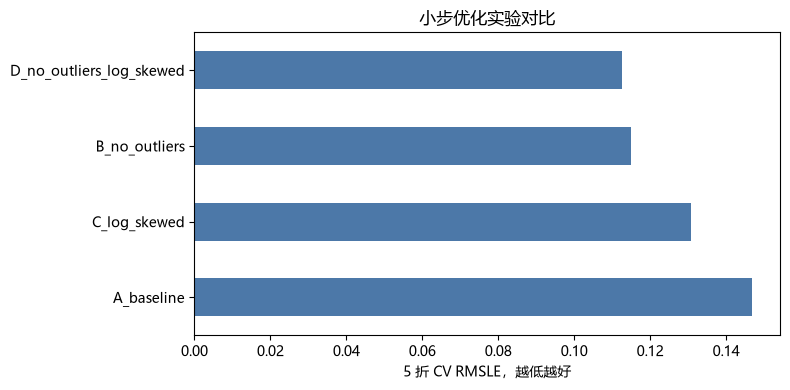

In [9]:
ax = results.sort_values("CV_RMSLE", ascending=False).plot(
    kind="barh",
    x="实验",
    y="CV_RMSLE",
    legend=False,
    figsize=(8, 4),
    color="#4C78A8",
)
ax.set_title("小步优化实验对比")
ax.set_xlabel("5 折 CV RMSLE，越低越好")
ax.set_ylabel("")
plt.tight_layout()

## 9. 生成当前最佳实验的提交文件

注意：本地 CV 不等于 Kaggle 公榜。这个文件只代表当前 notebook 中本地验证最好的实验，最终仍要提交到 Kaggle 验证。

In [10]:
best_experiment = results.iloc[0]["实验"]

if best_experiment == "A_baseline":
    final_X, final_y, final_X_test = X_base, y_base, X_test_base
elif best_experiment == "B_no_outliers":
    final_X, final_y, final_X_test = X_no_outliers, y_no_outliers, X_test_base
elif best_experiment == "C_log_skewed":
    final_X, final_y, final_X_test = X_log, y_base, X_test_log
else:
    final_X, final_y, final_X_test = X_no_outliers_log, y_no_outliers, X_test_no_outliers_log

final_model = build_ridge_model(final_X)
final_model.fit(final_X, final_y)
final_predictions = np.maximum(final_model.predict(final_X_test), 0)

SUBMISSION_DIR.mkdir(exist_ok=True)
submission = pd.DataFrame({"Id": test_ids, "SalePrice": final_predictions})
submission_path = SUBMISSION_DIR / "03_submission_improve_from_baseline.csv"
submission.to_csv(submission_path, index=False)

best_experiment, submission_path, submission.head()

('D_no_outliers_log_skewed',
 WindowsPath('C:/Users/84740/house-prices-advanced-regression/submissions/03_submission_improve_from_baseline.csv'),
      Id      SalePrice
 0  1461  119536.317378
 1  1462  154471.242875
 2  1463  184430.801899
 3  1464  199102.240023
 4  1465  195387.835972)

## 10. 下一步记录

提交 `03_submission_improve_from_baseline.csv` 后，把 Kaggle 公榜分数记录到 `99_submission_score_analysis.md`。如果它没有超过 baseline，就继续保留 baseline 为当前最好方案。